In [ ]:
# Установка библиотеки PyTorch.
!pip3 install torch

In [ ]:
import torch
print(torch.__version__)

2.10.0+cpu


# Обучение нейронной сети

## Ирисы Фишера

### Набор данных

 Вы будете работать с известным набором данных для тестирования моделей, чтобы решить задачу классификации [«Ирисы Фишера»](https://ru.wikipedia.org/wiki/%D0%98%D1%80%D0%B8%D1%81%D1%8B_%D0%A4%D0%B8%D1%88%D0%B5%D1%80%D0%B0).

 Набор состоит из информации о 150
 различных цветках ирисов, для каждого из которых известны следующие характеристики:

 1. Длина чашелистика (sepal length), см.
 1. Ширина чашелистика (sepal width), см.
 1. Длина лепестка (petal length), см.
 1. Ширина лепестка (petal width), см.

 Также для каждого из цветков известен один из трёх классов, которому он принадлежит:

 1. Ирис щетинистый (setosa).
 1. Ирис виргинский (virginica).
 1. Ирис разноцветный (versicolor).

 При решении задачи классификации, которая задаётся этим набором данных, нужно научиться по нескольким характеристикам цветка определять, к какому классу он принадлежит.

### Ирисы Фишера в Python

В Python ирисы Фишера доступны в библиотеке `sklearn`:

```
from sklearn import datasets

# в переменную будет сохранён объект «набор данных «Ирисы Фишера»
data = datasets.load_iris()  
```

Чтобы преобразовать набор данных к виду, в котором его будет удобно использовать при создании моделей в PyTorch, необходимо написать:


```
X = torch.tensor(data['data'])
y = torch.tensor(data['target'])
```

В результате в переменной $X$ будет находиться матрица размера $150 \times 4$, в которой каждая строчка соответствует конкретному цветку, а каждая из колонок — одной из его характеристик:

```
tensor([[5.1000, 3.5000, 1.4000, 0.2000],
        [4.9000, 3.0000, 1.4000, 0.2000],
        [4.7000, 3.2000, 1.3000, 0.2000],
        [4.6000, 3.1000, 1.5000, 0.2000],
        ...
        [5.9000, 3.0000, 5.1000, 1.8000]], dtype=torch.float64)
```

В переменной $y$ будет находиться вектор размера $150$. На $i$-й позиции в векторе стоит значение класса для $i$-го цветка из матрицы $X$:


```
tensor([0, 0, 0, 0, ... 2, 2, 2, 2])
```



In [ ]:
!pip3 install scikit-learn

In [ ]:
import sklearn
from sklearn import datasets

In [ ]:
# TODO: Загрузите датасет "Ирисы Фишера"

In [ ]:
# TODO: Преобразуйте обучающую выборку в тензоры Pytorch,
#       в переменную X сохраните признаковое описание объекта - характеристики цветков Ириса,
#       в переменную y сохраните целевую переменную - классы цветков Ириса.

In [ ]:
# TODO: С помощью функции train_test_split() из sklearn.model_selection
#       разделите данные на обучающую и тестовую выборку,
#       отправив в тестовую часть 20% данных

### Что нужно сделать?

В рамках задания вам будет необходимо реализовать нейронную сеть и обучить её для решения задачи классификации цветков из набора данных «Ирисы Фишера».

#### Создание нейронной сети

В этом блокноте ниже уже есть заготовка для решения задания.

В переменную $X$ помещена матрица с характеристиками цветков из набора, в переменную $y$ помещены значения классов, которые необходимо научиться предсказывать.

Вам необходимо заполнить пропущенные места в коде, придумав архитектуру нейронной сети, которая сможет решить поставленную задачу, а также запустить обучение полученной модели. Пропуски, которые необходимо заполнить, помечены комментарием TODO.

In [ ]:
import sklearn
from sklearn import datasets
from sklearn.model_selection import train_test_split

#  TODO: Загрузите датасет "Ирисы Фишера"
data = datasets.load_iris()

#  TODO: Преобразуйте данные в тензоры PyTorch
# X — признаки (150 объектов × 4 признака), y — целевые классы (0, 1, 2)
X = torch.tensor(data['data'], dtype=torch.float32)
y = torch.tensor(data['target'], dtype=torch.long)

#  TODO: Разделите данные на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% данных в тест
    random_state=42,    # фиксированный seed для воспроизводимости
    stratify=y          # сохраняем пропорции классов
)

print(f"Размер обучающей выборки: {X_train.shape}")  # (120, 4)
print(f"Размер тестовой выборки: {X_test.shape}")     # (30, 4)

Размер обучающей выборки: torch.Size([120, 4])
Размер тестовой выборки: torch.Size([30, 4])


In [ ]:
from collections import OrderedDict
import torch.nn as nn

#  TODO: Реализуйте модель нейронной сети
# Архитектура: 4 входа → скрытый слой (16 нейронов) → выход (3 класса)
# На последнем слое используем LogSoftmax для совместимости с NLLLoss

model = nn.Sequential(OrderedDict([
    ('fc1', nn.Linear(4, 16)),           # Полносвязный слой: 4 → 16
    ('relu1', nn.ReLU()),                 # Функция активации ReLU
    ('fc2', nn.Linear(16, 3)),           # Полносвязный слой: 16 → 3 (класса)
    ('logsoftmax', nn.LogSoftmax(dim=1)) # Логарифмическая функция активации
]))

# Приводим модель к тому же типу данных, что и входные тензоры
model = model.to(dtype=X.dtype)

# Вывод архитектуры модели
print(model)

Sequential(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=16, out_features=3, bias=True)
  (logsoftmax): LogSoftmax(dim=1)
)


In [ ]:
!pip3 install matplotlib

In [ ]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
%matplotlib inline

#  TODO: Число итераций обучения (больше 1000)
num_epochs = 2000

#  TODO: Создайте оптимизатор SGD с lr=0.01
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

#  TODO: Задайте функцию потерь NLLLoss (Negative Log Likelihood)
# Работает в паре с LogSoftmax на последнем слое
loss_fn = nn.NLLLoss()

# Списки для хранения истории обучения
losses = []
test_accuracy_history = []

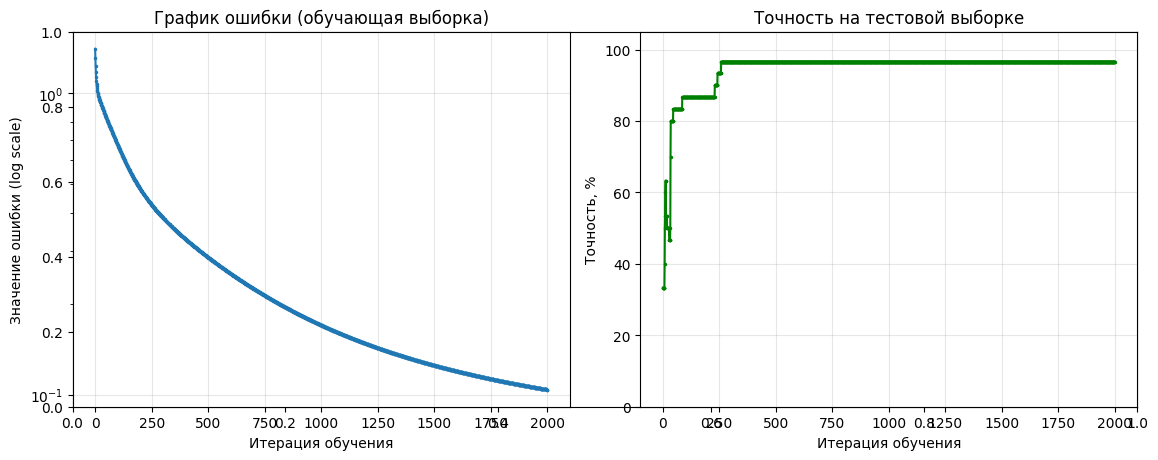

Эпоха 2000/2000 | Loss: 0.1040 | Test Acc: 96.67%


In [ ]:
for epoch in range(1, num_epochs + 1):
    # TODO: Обнуляем градиенты перед каждым шагом
    optimizer.zero_grad()

    # TODO: Прямой проход — предсказание модели на обучающих данных
    pred = model(X_train)

    # TODO: Вычисляем функцию потерь
    loss = loss_fn(pred, y_train)

    # TODO: Обратный проход — вычисление градиентов
    loss.backward()

    # TODO: Шаг оптимизации — обновление весов модели
    optimizer.step()

    # Сохраняем значение потери для графика
    losses.append(loss.item())

    # Оценка точности на тестовой выборке (без вычисления градиентов)
    with torch.no_grad():
        test_preds = model(X_test)
        # Сравниваем предсказанные классы с истинными
        accuracy = (test_preds.argmax(dim=1) == y_test).float().mean()
        test_accuracy_history.append(accuracy)

    # Визуализация прогресса каждые 100 эпох
    if epoch % 100 == 0:
        clear_output(True)
        fig, ax = plt.subplots(figsize=(12, 5))

        # График потерь
        plt.subplot(1, 2, 1)
        plt.title("График ошибки (обучающая выборка)")
        plt.plot(losses, ".-", markersize=3)
        plt.xlabel("Итерация обучения")
        plt.ylabel("Значение ошибки (log scale)")
        plt.yscale("log")
        plt.grid(True, alpha=0.3)

        # График точности на тесте
        plt.subplot(1, 2, 2)
        plt.title("Точность на тестовой выборке")
        plt.plot([acc * 100 for acc in test_accuracy_history], ".-", color='green', markersize=3)
        plt.xlabel("Итерация обучения")
        plt.ylabel("Точность, %")
        plt.ylim(0, 105)
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        print(f"Эпоха {epoch}/{num_epochs} | Loss: {loss.item():.4f} | Test Acc: {accuracy * 100:.2f}%")

## Получение предсказания на тестовой выборке
В качестве ответа присвойте переменной y_pred список предсказанных классов для тестовыой выборки


In [ ]:
# Модель возвращает логарифмы вероятностей для каждого класса
log_probs = model(X_test)

# Преобразуем логарифмы в вероятности (опционально, для интерпретации)
pred_class_probs = log_probs.exp()

# Выбираем класс с максимальной вероятностью для каждого объекта
pred_class = torch.argmax(log_probs, dim=1)

#  Вывод предсказаний
print("Предсказанные классы:", pred_class.numpy())
print("Истинные классы:     ", y_test.numpy())

Предсказанные классы: [0 2 1 1 0 1 0 0 2 2 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]
Истинные классы:      [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


#### Ответ на тестовой выборке

In [ ]:
print(pred_class)

tensor([0, 2, 1, 1, 0, 1, 0, 0, 2, 2, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2, 1, 2,
        2, 1, 1, 0, 2, 0])


Посчитайте точность предсказаний, как долю верно предсказанных ответов

In [ ]:
# TODO: Посчитайте точность предсказаний как долю верных ответов
accuracy = (pred_class == y_test).float().mean().item()

print(f"\n🎯 Итоговая точность на тестовой выборке: {accuracy * 100:.2f}%")
print(f"Верно предсказано: {(pred_class == y_test).sum().item()} из {len(y_test)} образцов")


🎯 Итоговая точность на тестовой выборке: 96.67%
Верно предсказано: 29 из 30 образцов
